In [1]:
import os, time, random, warnings
warnings.filterwarnings("ignore")
 
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

def set_seed(s: int = 42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
 
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device : {device}")

device : cuda


In [2]:
DATA_DIR   = "/kaggle/input/datasets/vitthal2945/e2e-hidden-symmetries-dataset"
OUT_DIR    = "/kaggle/working/task3_exp2_nullspace"
LATENT_DIM = 16
N_CLASSES  = 2
DIG_MAP    = {1: 0, 2: 1}
 
EPOCHS_ORACLE = 20
EPOCHS_G      = 80
BATCH_SIZE    = 256
LR_ORACLE     = 1e-3
LR_G          = 1e-4
NG            = 2           # number of orthogonal null-space generators to learn
 
EPS_STEP   = 0.05           # step size for tangent consistency check
 
W_NULL  = 1.0
W_NORM  = 1.0
W_TANG  = 0.3
W_CURV  = 0.1
 
TASK1_CKPT = "/kaggle/input/models/vitthal2945/e2e-vaemodel/pytorch/default/1/best_model.pt"
os.makedirs(OUT_DIR, exist_ok=True)
print(f"output → {OUT_DIR}")

output → /kaggle/working/task3_exp2_nullspace


In [3]:
def load_h5(path: str):
    print(f"  loading {os.path.basename(path)} ...", end=" ", flush=True)
    t0 = time.time()
    with h5py.File(path, "r") as f:
        imgs   = torch.from_numpy(f["images"][:].astype("float32")).unsqueeze(1).clamp(0., 1.)
        labels = torch.from_numpy(f["labels"][:].astype("int64"))
        angles = torch.from_numpy(f["angles"][:].astype("int64"))
    print(f"done ({time.time()-t0:.1f}s)")
    return imgs, labels, angles
 
train_imgs, train_lbls, train_angs = load_h5(os.path.join(DATA_DIR, "rotated_mnist_train.h5"))
test_imgs,  test_lbls,  test_angs  = load_h5(os.path.join(DATA_DIR, "rotated_mnist_test.h5"))
 
def binary_filter(imgs, lbls, angs):
    mask = (lbls == 1) | (lbls == 2)
    return imgs[mask], lbls[mask], angs[mask]
 
tr_imgs, tr_lbls, tr_angs = binary_filter(train_imgs, train_lbls, train_angs)
te_imgs, te_lbls, te_angs = binary_filter(test_imgs,  test_lbls,  test_angs)
tr_cls = torch.tensor([DIG_MAP[l.item()] for l in tr_lbls])
te_cls = torch.tensor([DIG_MAP[l.item()] for l in te_lbls])

  loading rotated_mnist_train.h5 ... done (2.2s)
  loading rotated_mnist_test.h5 ... done (0.4s)


In [4]:
class ResBlock(nn.Module):
    def __init__(self, ch, g=8):
        super().__init__()
        g = min(g, ch)
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch), nn.SiLU(),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch),
        )
        self.act = nn.SiLU()
    def forward(self, x): return self.act(x + self.net(x))
 
class T1Encoder(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.stem  = nn.Sequential(nn.Conv2d(1, 32, 4, 2, 1, bias=False), nn.GroupNorm(8, 32), nn.SiLU())
        self.l1    = nn.Sequential(ResBlock(32),  nn.Conv2d(32,  64, 4, 2, 1, bias=False), nn.GroupNorm(8, 64), nn.SiLU())
        self.l2    = nn.Sequential(ResBlock(64),  nn.Conv2d(64, 128, 3, 2, 1, bias=False), nn.GroupNorm(8, 128), nn.SiLU())
        self.l3    = ResBlock(128)
        self.fc    = nn.Sequential(nn.Flatten(), nn.Linear(128*4*4, 512), nn.SiLU())
        self.fc_mu = nn.Linear(512, ld)
        self.fc_lv = nn.Linear(512, ld)
    def forward(self, x):
        h = self.l3(self.l2(self.l1(self.stem(x)))); h = self.fc(h)
        return self.fc_mu(h), self.fc_lv(h)
 
class T1Decoder(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(ld, 512), nn.SiLU(), nn.Linear(512, 128*4*4), nn.SiLU())
        self.u1 = nn.Sequential(ResBlock(128), nn.ConvTranspose2d(128, 64, 3, 2, 1, output_padding=1), nn.GroupNorm(8, 64), nn.SiLU())
        self.u2 = nn.Sequential(ResBlock(64),  nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.GroupNorm(8, 32), nn.SiLU())
        self.u3 = nn.Sequential(ResBlock(32),  nn.ConvTranspose2d(32, 1, 4, 2, 3), nn.Sigmoid())
    def forward(self, z): return self.u3(self.u2(self.u1(self.fc(z).view(-1, 128, 4, 4))))
 
class Task1VAE(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.encoder = T1Encoder(ld); self.decoder = T1Decoder(ld)
    def encode(self, x): mu, _ = self.encoder(x); return mu
    def decode(self, z): return self.decoder(z)
 
vae = Task1VAE(LATENT_DIM).to(device)
if os.path.exists(TASK1_CKPT):
    ck = torch.load(TASK1_CKPT, map_location=device, weights_only=False)
    vae.load_state_dict(ck["model"])
    print(f"Task-1 VAE loaded (epoch {ck['epoch']})")
else:
    print("⚠  TASK1_CKPT not found — set the correct path!")
vae.eval()
for p in vae.parameters(): p.requires_grad = False
 
# Pre-encode latent codes
@torch.no_grad()
def encode_split(imgs, cls_labels, batch=512):
    Z, C = [], []
    for i in range(0, len(imgs), batch):
        Z.append(vae.encode(imgs[i:i+batch].to(device)).cpu())
        C.append(cls_labels[i:i+batch])
    return torch.cat(Z), torch.cat(C)
 
print("Pre-encoding …")
Z_tr, C_tr = encode_split(tr_imgs, tr_cls)
Z_te, C_te = encode_split(te_imgs, te_cls)
print(f"Latent codes: train {Z_tr.shape}  test {Z_te.shape}")
 
z_tr_loader = DataLoader(TensorDataset(Z_tr, C_tr), batch_size=BATCH_SIZE, shuffle=True)
z_te_loader = DataLoader(TensorDataset(Z_te, C_te), batch_size=BATCH_SIZE, shuffle=False)

Task-1 VAE loaded (epoch 47)
Pre-encoding …
Latent codes: train torch.Size([152400, 16])  test torch.Size([26004, 16])


In [5]:
class BinaryOracle(nn.Module):
    def __init__(self, ld=LATENT_DIM, nc=N_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(ld, 256), nn.LayerNorm(256), nn.ReLU(),
            nn.Linear(256, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, nc),
        )
    def forward(self, z): return self.net(z)
 
psi = BinaryOracle().to(device)
opt_psi = torch.optim.Adam(psi.parameters(), lr=LR_ORACLE, weight_decay=1e-5)
 
print(f"\nTraining oracle ψ for {EPOCHS_ORACLE} epochs …")
for ep in range(1, EPOCHS_ORACLE + 1):
    psi.train()
    for z, c in z_tr_loader:
        z, c = z.to(device), c.to(device)
        opt_psi.zero_grad()
        F.cross_entropy(psi(z), c).backward()
        opt_psi.step()
    if ep % 5 == 0 or ep == 1:
        psi.eval()
        acc = sum((psi(z.to(device)).argmax(1) == c.to(device)).sum().item()
                  for z, c in z_te_loader) / len(Z_te)
        psi.train()
        print(f"  Oracle ep {ep:3d}/{EPOCHS_ORACLE}  val_acc={acc:.4f}")
 
# Keep oracle in eval mode but allow gradients through it for Jacobian computation
psi.eval()
# We do NOT freeze psi's parameters with requires_grad=False because we need
# autograd to flow through psi for the Jacobian computation.
# We freeze by wrapping calls appropriately.
psi_params_frozen = True
for p in psi.parameters(): p.requires_grad = False   # freeze weights
print("Oracle frozen (parameters), Jacobian computation still enabled via input grad.\n")


Training oracle ψ for 20 epochs …
  Oracle ep   1/20  val_acc=0.9957
  Oracle ep   5/20  val_acc=0.9957
  Oracle ep  10/20  val_acc=0.9955
  Oracle ep  15/20  val_acc=0.9950
  Oracle ep  20/20  val_acc=0.9954
Oracle frozen (parameters), Jacobian computation still enabled via input grad.



In [6]:
def oracle_jacobian(z: torch.Tensor) -> torch.Tensor:
    """
    Compute J(z) = ∂ψ(z)/∂z ∈ R^{B × k × ℓ} efficiently via vmap/jacobian.
    For small k (=2), we do two backward passes (one per output) via grad outputs.
    """
    z = z.detach().requires_grad_(True)
    psi_z = psi(z)  # (B, k)
    J_rows = []
    for c in range(N_CLASSES):
        # grad of ψ_c w.r.t. z: shape (B, ℓ)
        g = torch.autograd.grad(
            psi_z[:, c].sum(), z,
            create_graph=False,
            retain_graph=(c < N_CLASSES - 1)
        )[0]
        J_rows.append(g)   # each (B, ℓ)
    return torch.stack(J_rows, dim=1)  # (B, k, ℓ)

In [7]:
class NullSpaceGenerator(nn.Module):
    """
    Generates a vector field G(z) ∈ R^ℓ that is projected onto null(J(z)).
    
    Architecture: standard residual MLP. The null-space projection is applied
    OUTSIDE this module (in the loss function and evaluation), so this module
    is a standard MLP. The null-space constraint is enforced via L_null.
    
    This separation allows the MLP to learn a smooth global vector field
    while the algebraic constraint pulls it toward null(J(z)).
    """
    def __init__(self, ld: int = LATENT_DIM, hidden: int = 256):
        super().__init__()
        self.h1  = nn.Sequential(nn.Linear(ld, hidden), nn.LayerNorm(hidden), nn.GELU())
        self.h2  = nn.Sequential(nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.GELU())
        self.h3  = nn.Sequential(nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.GELU())
        self.out = nn.Linear(hidden, ld)
        nn.init.uniform_(self.out.weight, -0.01, 0.01)
        nn.init.zeros_(self.out.bias)
    def forward(self, z): return self.out(self.h3(self.h2(self.h1(z))))
 
    @staticmethod
    def project_to_nullspace(v: torch.Tensor, J: torch.Tensor) -> torch.Tensor:
        """
        Project vector v onto null(J) using SVD of J.
        J: (B, k, ℓ),  v: (B, ℓ)
        Returns: projected v̂ ∈ null(J), shape (B, ℓ)
        
        null(J) = I - J^† J  (orthogonal projector onto null space)
        For small k=2, we compute J^† via pseudo-inverse.
        """
        # J_pinv = J^T (J J^T)^{-1}: (B, ℓ, k)
        JJT = torch.bmm(J, J.transpose(1, 2))    # (B, k, k)
        JJT = JJT + 1e-6 * torch.eye(N_CLASSES, device=J.device).unsqueeze(0)
        JJT_inv = torch.linalg.inv(JJT)          # (B, k, k)
        J_pinv  = torch.bmm(J.transpose(1, 2), JJT_inv)  # (B, ℓ, k)
        # Projection: P_null v = v - J^† J v
        Jv      = torch.bmm(J, v.unsqueeze(2)).squeeze(2)   # (B, k)
        J_pinv_Jv = torch.bmm(J_pinv, Jv.unsqueeze(2)).squeeze(2)  # (B, ℓ)
        return v - J_pinv_Jv

In [8]:
def gram_schmidt_ortho(vecs: list) -> list:
    """
    Given a list of (B, ℓ) tensors, return orthogonalized list via Gram-Schmidt.
    Operates batch-wise (orthogonalizes the mean direction).
    """
    ortho = []
    for v in vecs:
        for u in ortho:
            # Project out u-component from v (using batch-mean inner product)
            proj = (v * u).sum(dim=1, keepdim=True) / (u * u).sum(dim=1, keepdim=True).clamp(1e-8)
            v = v - proj * u
        ortho.append(v)
    return ortho

In [9]:
def loss_null(G_vec: torch.Tensor, J: torch.Tensor) -> torch.Tensor:
    """
    L_null = ||J(z)·G(z)||²_F / (ℓ·k)
    J: (B, k, ℓ),  G_vec: (B, ℓ)
    """
    JG = torch.bmm(J, G_vec.unsqueeze(2)).squeeze(2)  # (B, k)
    return (JG ** 2).mean()
 
def loss_norm(G_vec: torch.Tensor) -> torch.Tensor:
    norms = G_vec.norm(dim=1)
    return ((norms - 1.0) ** 2).mean()
 
def loss_tang(generators: list, z: torch.Tensor, J_z: torch.Tensor, eps: float) -> torch.Tensor:
    """
    Tangent consistency: G(z_next) should also lie in null(J(z_next)).
    z_next = z + eps * G(z)
    """
    with torch.no_grad():
        z_next = z + eps * generators[0](z).detach()
    J_next = oracle_jacobian(z_next)   # (B, k, ℓ), with grad for L_null
    total = torch.tensor(0., device=z.device)
    for G in generators:
        g_next = G(z_next)
        total = total + loss_null(g_next, J_next)
    return total / len(generators)
 
def loss_curv(G_vec: torch.Tensor, J: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
    """
    Second-order curvature correction:
    L_curv = ||dJ/dz · G(z) · G(z)||²
    Approximated as: ||J(z + δG) - J(z)|| for small δ
    This measures how fast J changes along the generator direction.
    """
    delta = 0.01
    with torch.no_grad():
        z_d = z + delta * G_vec.detach()
    J_d  = oracle_jacobian(z_d).detach()
    dJ   = (J_d - J) / delta    # (B, k, ℓ): finite difference of J along G
    dJG  = torch.bmm(dJ, G_vec.unsqueeze(2)).squeeze(2)  # (B, k)
    return (dJG ** 2).mean()

In [10]:
generators = [NullSpaceGenerator().to(device) for _ in range(NG)]
all_params  = []
for G in generators: all_params.extend(G.parameters())
opt   = torch.optim.AdamW(all_params, lr=LR_G, weight_decay=1e-5)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_G)
 
history = {k: [] for k in ["null", "norm", "tang", "curv", "total",
                             "val_null", "val_true_drift"]}
best_val = float("inf")
 
print(f"Training {NG} null-space generators for {EPOCHS_G} epochs …\n")
 
for ep in range(1, EPOCHS_G + 1):
    for G in generators: G.train()
    acc = {k: 0. for k in ["null", "norm", "tang", "curv"]}
    n_b = 0
 
    for z, _ in z_tr_loader:
        z = z.to(device)
        opt.zero_grad(set_to_none=True)
    
        # Compute Jacobian
        J = oracle_jacobian(z)
        J_detached = J.detach()
    
        # Generator outputs (with Gram-Schmidt orthogonalization)
        raw_vecs = [G(z) for G in generators]
        g_vecs   = gram_schmidt_ortho(raw_vecs)
    
        # Losses
        l_null = sum(loss_null(gv, J_detached) for gv in g_vecs) / NG
        l_norm = sum(loss_norm(gv)             for gv in g_vecs) / NG
        l_tang = loss_tang(generators, z, J_detached, eps=EPS_STEP)
        l_curv = sum(loss_curv(gv, J_detached, z) for gv in g_vecs) / NG
    
        loss = W_NULL*l_null + W_NORM*l_norm + W_TANG*l_tang + W_CURV*l_curv
        loss.backward()
        nn.utils.clip_grad_norm_(all_params, 1.0)
        opt.step()
 
        acc["null"] += l_null.item()
        acc["norm"] += l_norm.item()
        acc["tang"] += l_tang.item()
        acc["curv"] += l_curv.item()
        n_b += 1
 
    sched.step()
    for k in acc: acc[k] /= n_b
    total = W_NULL*acc["null"] + W_NORM*acc["norm"] + W_TANG*acc["tang"] + W_CURV*acc["curv"]
 
    # Validation: null-space residual + true oracle drift
    for G in generators: G.eval()
    z_val = Z_te[:256].to(device)
    J_val = oracle_jacobian(z_val)
    
    with torch.no_grad():
        g_val = generators[0](z_val)
        JG_val = torch.bmm(J_val, g_val.unsqueeze(2)).squeeze(2)
        val_null = (JG_val ** 2).mean().item()
 
        # True oracle drift (functional, for verification)
        psi_0 = psi(z_val)
        z_new = z_val + EPS_STEP * g_val
        psi_new = psi(z_new)
        val_true_drift = F.mse_loss(psi_new, psi_0).item()
 
    for G in generators: G.train()
 
    for k in acc: history[k].append(acc[k])
    history["total"].append(total)
    history["val_null"].append(val_null)
    history["val_true_drift"].append(val_true_drift)
 
    tag = ""
    if val_null < best_val:
        best_val = val_null
        torch.save({"generators": [G.state_dict() for G in generators],
                    "oracle": psi.state_dict(), "epoch": ep,
                    "best_val_null": best_val},
                   os.path.join(OUT_DIR, "best_model.pt"))
        tag = "  ★"
 
    if ep % 10 == 0 or ep == 1 or tag:
        print(f"  ep {ep:3d}/{EPOCHS_G}  null={acc['null']:.5f}  "
              f"norm={acc['norm']:.5f}  tang={acc['tang']:.5f}  "
              f"val_null={val_null:.5f}  val_drift={val_true_drift:.8f}{tag}")
 
# Load best
ck = torch.load(os.path.join(OUT_DIR, "best_model.pt"), weights_only=False)
for i, G in enumerate(generators): G.load_state_dict(ck["generators"][i]); G.eval()
print(f"\nBest model loaded (epoch {ck['epoch']}, val_null={ck['best_val_null']:.5f})")

Training 2 null-space generators for 80 epochs …

  ep   1/80  null=0.10559  norm=0.67052  tang=0.10667  val_null=0.02735  val_drift=0.00006746  ★
  ep   4/80  null=0.02806  norm=0.50535  tang=0.02839  val_null=0.02593  val_drift=0.00006391  ★
  ep   5/80  null=0.02584  norm=0.48840  tang=0.02604  val_null=0.01659  val_drift=0.00004119  ★
  ep   8/80  null=0.02098  norm=0.46396  tang=0.02099  val_null=0.01597  val_drift=0.00004055  ★
  ep  10/80  null=0.01947  norm=0.45319  tang=0.01954  val_null=0.01716  val_drift=0.00004303
  ep  11/80  null=0.01871  norm=0.44748  tang=0.01872  val_null=0.01515  val_drift=0.00003693  ★
  ep  12/80  null=0.01795  norm=0.44098  tang=0.01795  val_null=0.01207  val_drift=0.00002930  ★
  ep  18/80  null=0.01572  norm=0.41870  tang=0.01574  val_null=0.01123  val_drift=0.00002747  ★
  ep  20/80  null=0.01549  norm=0.41301  tang=0.01544  val_null=0.01517  val_drift=0.00003553
  ep  30/80  null=0.01283  norm=0.39055  tang=0.01286  val_null=0.01181  val_drift=

In [11]:
def evaluate():
    z_val = Z_te[:500].to(device)

    # Jacobian needs gradients
    J_val = oracle_jacobian(z_val)

    # M1: Null-space alignment
    alignment = []
    with torch.no_grad():
        for G in generators:
            gv    = G(z_val)
            JG    = torch.bmm(J_val, gv.unsqueeze(2)).squeeze(2)
            ratio = 1.0 - (JG.norm(dim=1) / gv.norm(dim=1).clamp(1e-8)).mean().item()
            alignment.append(ratio)

    # M2: Drift
    drift_orbits = []
    with torch.no_grad():
        for G in generators:
            drifts = []
            z_t    = z_val.clone()
            psi_0  = psi(z_val)
            for _ in range(12):
                z_t = z_t + EPS_STEP * G(z_t)
                drifts.append(F.mse_loss(psi(z_t), psi_0).item())
            drift_orbits.append(drifts)

    # M3: Orthogonality
    with torch.no_grad():
        if NG > 1:
            g0 = generators[0](z_val)
            g1 = generators[1](z_val)
            ortho_err = F.cosine_similarity(g0, g1, dim=1).abs().mean().item()
        else:
            ortho_err = 0.

    return alignment, drift_orbits, ortho_err
 
alignment, drift_orbits, ortho_err = evaluate()
 
# M4: Rotation discovery (post-hoc using angle labels)
@torch.no_grad()
def rotation_alignment():
    from torchvision.transforms.functional import rotate as tvrotate
    from torchvision import transforms as T
    pool = ((te_lbls==1)|(te_lbls==2)) & (te_angs == 0)
    idx  = pool.nonzero(as_tuple=True)[0][:200]
    x0   = te_imgs[idx].to(device)
    x30  = tvrotate(x0, 30., interpolation=T.InterpolationMode.BILINEAR, fill=[0.])
    z0   = vae.encode(x0); z30 = vae.encode(x30)
    rot  = (z30 - z0)  # true rotation displacement
    sims = []
    for G in generators:
        gv = G(z0)
        sims.append(F.cosine_similarity(rot, gv, dim=1).abs().mean().item())
    return sims
 
cos_sims = rotation_alignment()
 
print("\n══════════════ FINAL METRICS ══════════════")
for i in range(NG):
    print(f"G_{i+1}:")
    print(f"  M1 Null-space alignment   : {alignment[i]:.4f}  [1.0 = perfect]")
    print(f"  M2 Oracle drift (12 steps): {drift_orbits[i][-1]:.5f}")
    print(f"  M4 Rotation cosine sim    : {cos_sims[i]:.4f}")
print(f"M3 Inter-generator ortho err : {ortho_err:.5f}  [0 = perfect]")
print("═══════════════════════════════════════════")
 
np.save(os.path.join(OUT_DIR, "metrics.npy"), {
    "exp": "EXP2_JACOBIAN_NULLSPACE",
    "null_space_alignment": alignment,
    "drift_orbits": drift_orbits,
    "ortho_error": ortho_err,
    "rotation_cosine_sims": cos_sims,
    "history": {k: history[k] for k in history},
}, allow_pickle=True)


══════════════ FINAL METRICS ══════════════
G_1:
  M1 Null-space alignment   : 0.6531  [1.0 = perfect]
  M2 Oracle drift (12 steps): 0.01048
  M4 Rotation cosine sim    : 0.2411
G_2:
  M1 Null-space alignment   : 0.5943  [1.0 = perfect]
  M2 Oracle drift (12 steps): 0.02954
  M4 Rotation cosine sim    : 0.2621
M3 Inter-generator ortho err : 0.17604  [0 = perfect]
═══════════════════════════════════════════


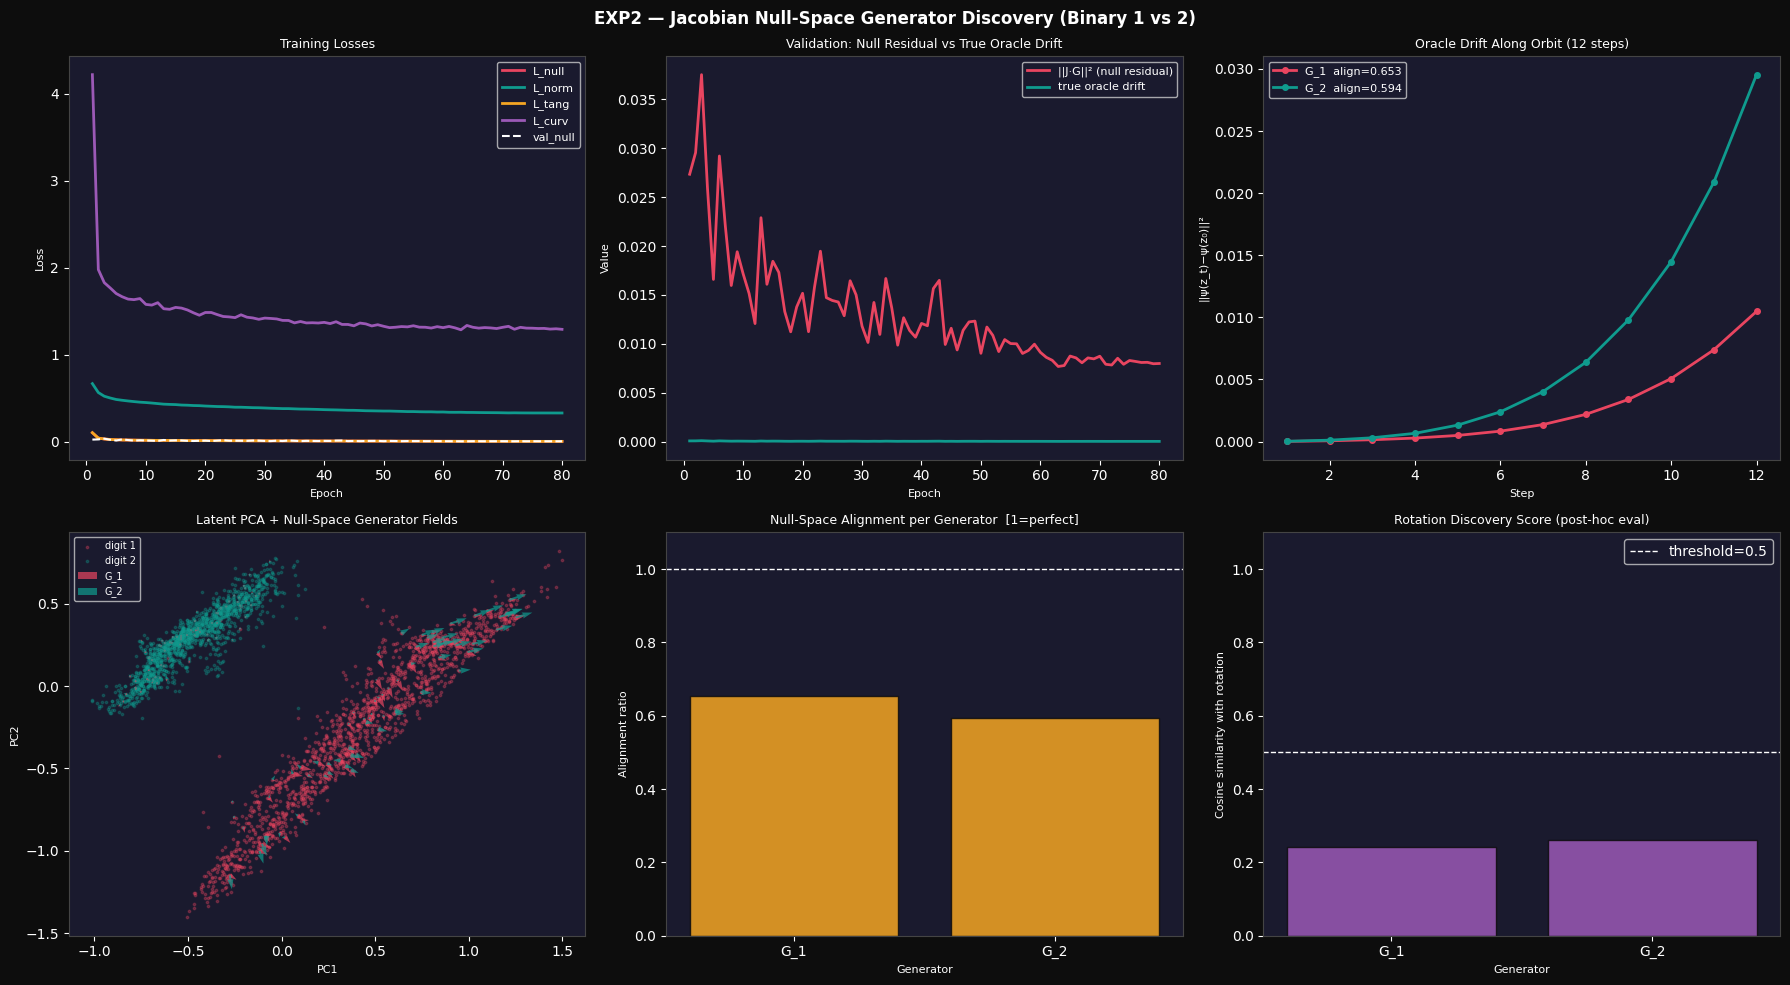

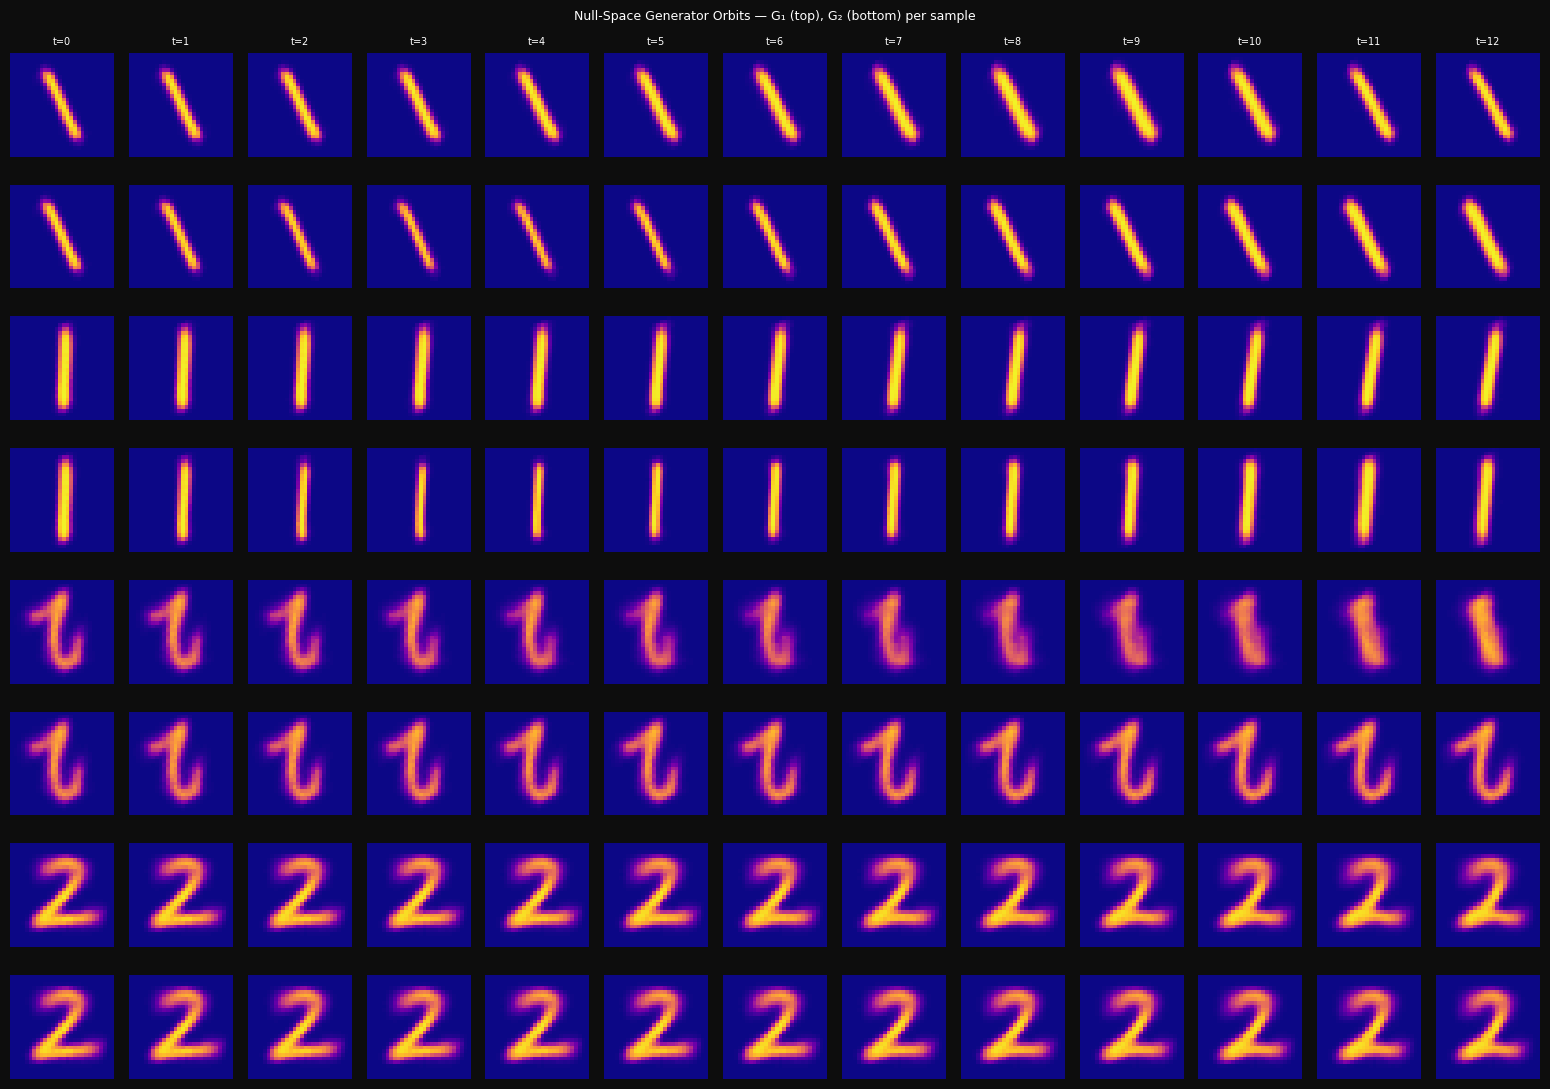


✅ EXP2 — Jacobian Null-Space complete
   Best rotation alignment: 0.2621
   Null-space alignment: ['0.6531', '0.5943']


In [12]:
DARK = "#0d0d0d"; PANEL = "#1a1a2e"
CMAP_G = ["#e94560", "#0f9b8e"]
 
def _ax(ax, title="", xl="", yl=""):
    ax.set_facecolor(PANEL); ax.tick_params(colors="white")
    for s in ax.spines.values(): s.set_edgecolor("#444")
    if title: ax.set_title(title, color="white", fontsize=9)
    if xl:    ax.set_xlabel(xl, color="white", fontsize=8)
    if yl:    ax.set_ylabel(yl, color="white", fontsize=8)
 
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor=DARK)
fig.suptitle("EXP2 — Jacobian Null-Space Generator Discovery (Binary 1 vs 2)",
             color="white", fontsize=12, fontweight="bold")
 
ep_x = range(1, EPOCHS_G + 1)
_ax(axes[0,0], "Training Losses", "Epoch", "Loss")
axes[0,0].plot(ep_x, history["null"],      color="#e94560", lw=2, label="L_null")
axes[0,0].plot(ep_x, history["norm"],      color="#0f9b8e", lw=2, label="L_norm")
axes[0,0].plot(ep_x, history["tang"],      color="#f5a623", lw=2, label="L_tang")
axes[0,0].plot(ep_x, history["curv"],      color="#9b59b6", lw=2, label="L_curv")
axes[0,0].plot(ep_x, history["val_null"],  color="white", lw=1.5, ls="--", label="val_null")
axes[0,0].legend(facecolor=PANEL, labelcolor="white", fontsize=8)
 
_ax(axes[0,1], "Validation: Null Residual vs True Oracle Drift", "Epoch", "Value")
axes[0,1].plot(ep_x, history["val_null"],       color="#e94560", lw=2, label="||J·G||² (null residual)")
axes[0,1].plot(ep_x, history["val_true_drift"], color="#0f9b8e", lw=2, label="true oracle drift")
axes[0,1].legend(facecolor=PANEL, labelcolor="white", fontsize=8)
 
_ax(axes[0,2], "Oracle Drift Along Orbit (12 steps)", "Step", "||ψ(z_t)−ψ(z₀)||²")
for i, dc in enumerate(drift_orbits):
    axes[0,2].plot(range(1, 13), dc, color=CMAP_G[i], lw=2, marker="o", ms=4,
                   label=f"G_{i+1}  align={alignment[i]:.3f}")
axes[0,2].legend(facecolor=PANEL, labelcolor="white", fontsize=8)
 
# Latent PCA + null-space generator fields
pca    = PCA(n_components=2).fit(Z_te[:3000].numpy())
z2_all = pca.transform(Z_te[:3000].numpy())
c_all  = C_te[:3000].numpy()
 
_ax(axes[1,0], "Latent PCA + Null-Space Generator Fields", "PC1", "PC2")
axes[1,0].scatter(z2_all[c_all==0,0], z2_all[c_all==0,1], s=3, alpha=0.3, color="#e94560", label="digit 1")
axes[1,0].scatter(z2_all[c_all==1,0], z2_all[c_all==1,1], s=3, alpha=0.3, color="#0f9b8e", label="digit 2")
idx_q = np.random.choice(3000, 150, replace=False)
z_q   = torch.from_numpy(Z_te[:3000][idx_q].numpy()).to(device)
with torch.no_grad():
    for i, G in enumerate(generators):
        gv = G(z_q).cpu().numpy() @ pca.components_.T
        axes[1,0].quiver(z2_all[idx_q,0], z2_all[idx_q,1], gv[:,0], gv[:,1],
                         color=CMAP_G[i], alpha=0.7, scale=25, width=0.004, label=f"G_{i+1}")
axes[1,0].legend(facecolor=PANEL, labelcolor="white", fontsize=7)
 
# Null-space alignment bars
_ax(axes[1,1], "Null-Space Alignment per Generator  [1=perfect]", "Generator", "Alignment ratio")
axes[1,1].bar(range(NG), alignment, color="#f5a623", alpha=0.85, edgecolor=DARK)
axes[1,1].axhline(1.0, color="white", ls="--", lw=1)
axes[1,1].set_xticks(range(NG))
axes[1,1].set_xticklabels([f"G_{i+1}" for i in range(NG)], color="white")
axes[1,1].set_ylim(0, 1.1)
 
# Rotation cosine similarity
_ax(axes[1,2], "Rotation Discovery Score (post-hoc eval)", "Generator", "Cosine similarity with rotation")
axes[1,2].bar(range(NG), cos_sims, color="#9b59b6", alpha=0.85, edgecolor=DARK)
axes[1,2].axhline(0.5, color="white", ls="--", lw=1, label="threshold=0.5")
axes[1,2].set_xticks(range(NG))
axes[1,2].set_xticklabels([f"G_{i+1}" for i in range(NG)], color="white")
axes[1,2].set_ylim(0, 1.1)
axes[1,2].legend(facecolor=PANEL, labelcolor="white")
 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "results.png"), dpi=150, bbox_inches="tight", facecolor=DARK)
plt.show()
 
# Orbit visualization
@torch.no_grad()
def plot_orbits(n_samples=4, n_steps=13):
    idx1 = (C_te==0).nonzero(as_tuple=True)[0][:n_samples//2]
    idx2 = (C_te==1).nonzero(as_tuple=True)[0][:n_samples//2]
    pool = torch.cat([idx1, idx2]).tolist()
    fig, axes = plt.subplots(n_samples * 2, n_steps,
                              figsize=(n_steps*1.2, n_samples*2.8), facecolor=DARK)
    fig.suptitle("Null-Space Generator Orbits — G₁ (top), G₂ (bottom) per sample",
                 color="white", fontsize=9)
    for row, idx in enumerate(pool):
        for gi, G in enumerate(generators):
            z = Z_te[idx:idx+1].to(device)
            for col in range(n_steps):
                ax = axes[row*2 + gi, col]
                img = vae.decoder(z).clamp(0.,1.).cpu().squeeze().numpy()
                ax.imshow(img, cmap="plasma", vmin=0, vmax=1); ax.axis("off")
                if row == 0 and gi == 0: ax.set_title(f"t={col}", color="white", fontsize=7)
                if col < n_steps-1: z = z + EPS_STEP * G(z)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "orbits.png"), dpi=150, bbox_inches="tight", facecolor=DARK)
    plt.show()
 
plot_orbits()
print(f"\n✅ EXP2 — Jacobian Null-Space complete")
print(f"   Best rotation alignment: {max(cos_sims):.4f}")
print(f"   Null-space alignment: {[f'{a:.4f}' for a in alignment]}")
 